# Assignment: Linear Models


**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (This is a trick question, and the trick involves how you handle the intercept of the model.)
3. Can linear regression be used for classification? Explain why, or why not.
4. What are signs that your linear model is over-fitting?
5. Clearly explain multi-colinearity using the two-stage least squares technique.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
7. What is the interpretation of the intercept? A slope coefficient for a variable? The coefficient for a dummy/one-hot-encoded variable?

1. A model is "linear" because the coefficients, $b$ enter the prediction as $\hat{y} = b ⋅ \hat{x} = b_1 \hat{x_1} + b_2 \hat{x_2} + ...b_j \hat{x_j}$. The relationship between $\hat{y}$ and each $\hat{x_j}$ is a linear one through $b_j$. In other words, the model is linear because the weights $b$ enter the model in a multiplicative way.


**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood `: The bourough of NYC. Note the space, or rename the variable.
- `Property Type`: The kind of dwelling
- `Room Type`: The kind of space being rented

1. Compute the average prices and scores by `Neighbourhood `; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood `.
2. Regress price on `Neighbourhood ` by creating the appropriate dummy/one-hot-encoded variables, without an intercept in the linear model and using all the data. Compare the coefficients in the regression to the table from part 1. What pattern do you see? What are the coefficients in a regression of a continuous variable on one categorical variable?
3. Repeat part 2, but leave an intercept in the linear model. How do you have to handle the creation of the dummies differently? What is the intercept? Interpret the coefficients. How can I get the coefficients in part 2 from these new coefficients?
4. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighbourhood `. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
5. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighbourhood ` and `Property Type`. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
6. What does the coefficient on `Review Scores Rating` mean if it changes from part 4 to 5? Hint: Think about how multilple linear regression works.
7. (Optional) We've included `Neighborhood ` and `Property Type` separately in the model. How do you interact them, so you can have "A bedroom in Queens" or "A townhouse in Manhattan". Split the sample 80/20 into a training and a test set and run a regression including that kind of "property type X neighborhood" dummy, plus `Review Scores Rating`. How does the slope coefficient for `Review Scores Rating`, the $R^2$, and the RMSE change? Do they increase significantly compares to part 5? Are the coefficients in this regression just the sum of the coefficients for `Neighbourhood ` and `Property Type` from 5? What is the most expensive kind of property you can rent?

In [1]:
!git clone https://github.com/siwenliao/linear_models
%cd linear_models/assignment

Cloning into 'linear_models'...
remote: Enumerating objects: 68, done.
remote: Counting objects: 100% (30/30), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 68 (delta 20), reused 12 (delta 12), pack-reused 38 (from 1)
Receiving objects: 100% (68/68), 3.60 MiB | 15.31 MiB/s, done.
Resolving deltas: 100% (20/20), done.
/content/linear_models/assignment


Average price by neighborhood: 
 Neighbourhood 
Bronx             75.276498
Brooklyn         127.747378
Manhattan        183.664286
Queens            96.857233
Staten Island    146.166667
Name: Price, dtype: float64 

Average scores by neighborhood: 
 Neighbourhood 
Bronx            91.654378
Brooklyn         92.363497
Manhattan        91.801496
Queens           91.549057
Staten Island    90.843750
Name: Review Scores Rating, dtype: float64 

Most expensive borough on average: Manhattan 



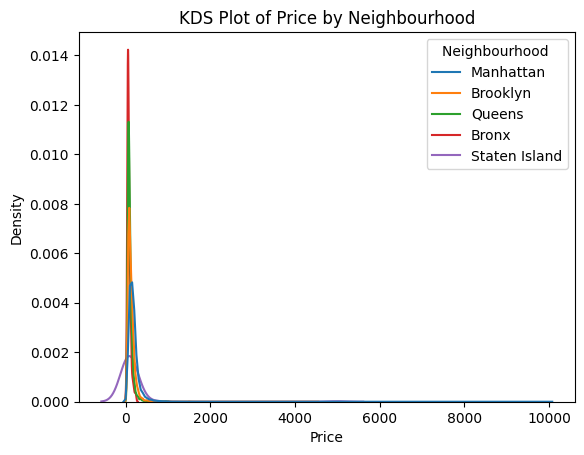

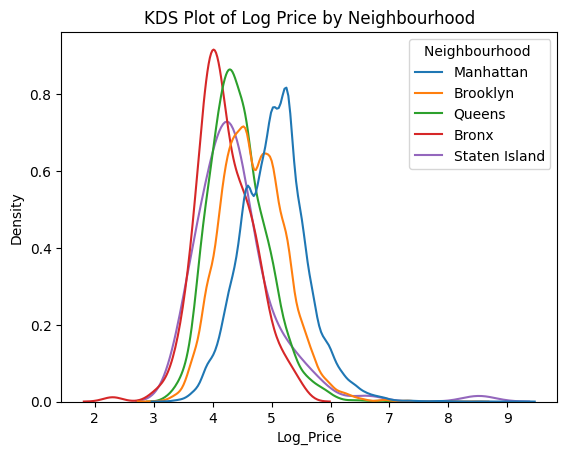

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Q2: Load ./data/Q1_clean.csv
clean_df = pd.read_csv('./data/Q1_clean.csv')
clean_df.head()

# 1: Averages and KDE Plots
average_price = clean_df.groupby('Neighbourhood ')['Price'].mean()
print('Average price by neighborhood: \n', average_price, '\n')
average_score = clean_df.groupby('Neighbourhood ')['Review Scores Rating'].mean()
print('Average scores by neighborhood: \n', average_score, '\n')

print("Most expensive borough on average:", average_price.idxmax(), '\n')

plt.figure()
sns.kdeplot(data=clean_df, x='Price', hue='Neighbourhood ', common_norm=False).set(title='KDS Plot of Price by Neighbourhood')
plt.show()


clean_df['Log_Price'] = np.log(clean_df['Price'])
plt.figure()
sns.kdeplot(data=clean_df, x='Log_Price', hue='Neighbourhood ', common_norm=False).set(title='KDS Plot of Log Price by Neighbourhood')
plt.show()

Manhattan is the most expensive bourough on average.

In [3]:
# 2: Regress Price on Neighborhood, Without Intercept

from sklearn.linear_model import LinearRegression

y = clean_df['Price']
X = pd.get_dummies(clean_df['Neighbourhood '])

reg = LinearRegression(fit_intercept=False).fit(X, y)
print(reg.intercept_)
print(reg.coef_)
print(reg.score(X,y))

0.0
[ 75.2764977  127.74737834 183.66428632  96.8572327  146.16666667]
0.04631389606035197


In [15]:
print('Comparing coefficients to the table from part 1: \n')
print(reg.coef_, '\n')
print(average_price, '\n')

Comparing coefficients to the table from part 1: 

[ 52.47088065 108.38778863  21.58073501  70.89016897] 

Neighbourhood 
Bronx             75.276498
Brooklyn         127.747378
Manhattan        183.664286
Queens            96.857233
Staten Island    146.166667
Name: Price, dtype: float64 



The coefficients in the regression are approximately the same as the table of average prices from part 1. The coefficients in a regression of a continuous variable on one categorical variable without the intercept represent the averages of the continuous variable for each categorical variable.

In [14]:
# 3: Regress Price on Neighborhood, With Intercept

y = clean_df['Price']
X = pd.get_dummies(clean_df['Neighbourhood '], drop_first=True)

reg = LinearRegression().fit(X, y)
print(reg.intercept_)
print(reg.coef_)
print(reg.score(X,y))

75.27649769585331
[ 52.47088065 108.38778863  21.58073501  70.89016897]
0.04631389606035197


When running linear regression with dummy variables, we have two choices:


1.   For each dummy variable, use the pd.get_dummies(..., drop_first=True), and keep the intercept in the regression.
2.   Drop the intercept with the option LinearRegression(fit_intercept=False).fit(X,y), but keep all the dummies.

We have to make these choices because if you have an intercept and all of the dummies, you can replicate one of your regressors from a combination of other ones. This is called perfect multicolinearity, and some of your coefficents won't be defined. So, in part 2, we followed 2), and in this part, we followed 1). In other words, when creating the dummmies, we used pd.get_dummies(..., drop_first=True), which is different from part 2. The intercept is 75.27649769585331. This means that the mean price of the reference neighborhood is 75.27649769585331. The coefficients can be interpreted as the difference in predicted price when switching neighborhoods. For example, for a coefficient of 52.47, the prices in that neighborhood are on average about $52.47 more expensive than the reference neighborhood. To get the coefficients in part 2 from these new coefficients, you would just add the intercept to each coefficient.


In [21]:
# 4: Regression of Price on Review Scores Rating and Neighbourhood

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

X = clean_df[['Review Scores Rating', 'Neighbourhood ']]
y = clean_df['Price']

X = pd.get_dummies(X, columns = ['Neighbourhood '], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X,y,
                                                    test_size=.2,
                                                    random_state=65)
reg = LinearRegression().fit(X_train, y_train)
y_pred = reg.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print('Test R^2:', r2, '\n')
print('Test RMSE:', rmse, '\n')

coef_table = pd.Series(reg.coef_, index=X.columns)
print('Coefficients:')
print(coef_table, '\n')

print('Intercept: \n')
print(reg.intercept_, '\n')

print('Coefficient on Review Scores Rating: \n')
print(coef_table['Review Scores Rating'])

Test R^2: 0.029117109332052915 

Test RMSE: 194.0474943299375 

Coefficients:
Review Scores Rating              1.016096
Neighbourhood _Brooklyn          51.183175
Neighbourhood _Manhattan        107.929122
Neighbourhood _Queens            21.684993
Neighbourhood _Staten Island     83.136957
dtype: float64 

Intercept: 

-17.99035402608709 

Coefficient on Review Scores Rating: 

1.01609586375163


The most expensive neighborhood you can rent from is Manhattan.

In [22]:
# 5: Regression of Price on Review Scores Rating, Neighbourhood, and Property Type

X = clean_df[['Review Scores Rating', 'Neighbourhood ', 'Property Type']]
y = clean_df['Price']

X = pd.get_dummies(X, columns = ['Neighbourhood ', 'Property Type'], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X,y,
                                                    test_size=.2,
                                                    random_state=65)
reg = LinearRegression().fit(X_train, y_train)
y_pred = reg.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print('Test R^2:', r2, '\n')
print('Test RMSE:', rmse, '\n')

coef_table = pd.Series(reg.coef_, index=X.columns)
print('Coefficients:')
print(coef_table, '\n')

print('Intercept: \n')
print(reg.intercept_, '\n')

print('Coefficient on Review Scores Rating: \n')
print(coef_table['Review Scores Rating'])


Test R^2: 0.0334068421154583 

Test RMSE: 193.61833164635303 

Coefficients:
Review Scores Rating               1.002221
Neighbourhood _Brooklyn           57.696138
Neighbourhood _Manhattan         119.462994
Neighbourhood _Queens             26.643774
Neighbourhood _Staten Island      75.535223
Property Type_Bed & Breakfast    -35.946530
Property Type_Boat                56.390135
Property Type_Bungalow            27.568490
Property Type_Cabin               35.174425
Property Type_Camper/RV          -14.920886
Property Type_Castle             -39.765165
Property Type_Chalet             -27.996088
Property Type_Condominium        102.485292
Property Type_Dorm               -48.558115
Property Type_House               31.105038
Property Type_Hut               -133.751840
Property Type_Lighthouse         -88.998309
Property Type_Loft                62.824561
Property Type_Other               45.220652
Property Type_Townhouse           78.254245
Property Type_Treehouse          -75.737405

The most expensive property you can rent is a condominium.

Q6: The coefficient on Review Scores Rating, if it changes from part 4 to 5, means that it is influenced by Property Type. This means that Property Type is a confounding variable between using Review Scores Rating to predict price.

In [66]:
# 7: Regression of Price on Review Scores Rating and the Interaction of Neighbourhood and Property Type

from sklearn.preprocessing import PolynomialFeatures

y = clean_df['Price']

X_neigh = pd.get_dummies(clean_df['Neighbourhood '], drop_first=True)
X_prop = pd.get_dummies(clean_df['Property Type'], drop_first=True)

X_inter = pd.DataFrame()
for n_col in X_neigh.columns:
    for p_col in X_prop.columns:
        X_inter[f'{n_col} X {p_col}'] = X_neigh[n_col] * X_prop[p_col]

X = pd.concat([clean_df[['Review Scores Rating']], X_neigh, X_prop, X_inter], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X,y,
                                                    test_size=.2,
                                                    random_state=65)
reg = LinearRegression().fit(X_train, y_train)
y_pred = reg.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print('Test R^2:', r2, '\n')
print('Test RMSE:', rmse, '\n')

coef_table = pd.Series(reg.coef_, index=X.columns)
print('Coefficients:')
print(coef_table, '\n')

print('Intercept: \n')
print(reg.intercept_, '\n')

print('Coefficient on Review Scores Rating: \n')
print(coef_table['Review Scores Rating'])


Test R^2: 0.03784920824353977 

Test RMSE: 193.17289395142646 

Coefficients:
Review Scores Rating           0.999423
Brooklyn                      46.920927
Manhattan                    103.022315
Queens                        22.197648
Staten Island                 23.028419
                                ...    
Staten Island X Loft           0.000000
Staten Island X Other        -33.449178
Staten Island X Townhouse    -83.024377
Staten Island X Treehouse      0.000000
Staten Island X Villa          0.000000
Length: 90, dtype: float64 

Intercept: 

-15.97544681733686 

Coefficient on Review Scores Rating: 

0.9994225871006616


In [68]:
print(coef_table.sort_values(ascending=False).head(10))

Manhattan X House          131.944091
Manhattan X Loft           108.489603
Manhattan X Townhouse      103.701624
Manhattan                  103.022315
Staten Island X House       99.926855
Manhattan X Other           96.458196
Manhattan X Condominium     74.584406
Condominium                 63.021640
Loft                        50.692348
Queens X Boat               50.651900
dtype: float64


The slope coefficient for Review Scores Rating decreases slightly from 1.0022207483987255 to 0.9994225871006616. 𝑅2 increases, and the RMSE decreases, but the changes in the metrics are very small. The coefficients in this regression are not just the sum of the coefficients for Neighbourhood and Property Type from part 5. The most expensive kind of property you can rent is a house in Manhattan.

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`, `Color`, `Seating_Capacity`
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make`, `Make_Year`: The brand of car and year produced
  - `Mileage_Run`: The number of miles on the odometer
  - `Fuel_Type`: Diesel or gasoline/petrol
  - `Transmission`, `Transmission_Type`:  speeds and automatic/manual

  1. Load `cars_hw.csv`. These data were really dirty, and I've already cleaned them a significant amount in terms of missing values and other issues, but some issues remain (e.g. outliers, badly scaled variables that require a log or arcsinh transformation). Clean the data however you think is most appropriate.
  2. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by brand (`Make`). Make a grouped kernel density plot by `Make`. Which car brands are the most expensive? What do prices look like in general?
  3. Split the data into an 80% training set and a 20% testing set.
  4. Make a model where you regress price on the numeric variables alone; what is the $R^2$ and `RMSE` on the training set and test set? Make a second model where, for the categorical variables, you regress price on a model comprised of one-hot encoded regressors/features alone (you can use `pd.get_dummies()`; be careful of the dummy variable trap); what is the $R^2$ and `RMSE` on the test set? Which model performs better on the test set? Make a third model that combines all the regressors from the previous two; what is the $R^2$ and `RMSE` on the test set? Does the joint model perform better or worse, and by home much?
  5. Use the `PolynomialFeatures` function from `sklearn` to expand the set of numerical variables you're using in the regression. As you increase the degree of the expansion, how do the $R^2$ and `RMSE` change? At what point does $R^2$ go negative on the test set? For your best model with expanded features, what is the $R^2$ and `RMSE`? How does it compare to your best model from part 4?
  6. For your best model so far, determine the predicted values for the test data and plot them against the true values. Do the predicted values and true values roughly line up along the diagonal, or not? Compute the residuals/errors for the test data and create a kernel density plot. Do the residuals look roughly bell-shaped around zero? Evaluate the strengths and weaknesses of your model.

In [69]:
# 1: Load Data and Clean

cars_df = pd.read_csv('./data/cars_hw.csv')
print(cars_df.head(), '\n')
print(cars_df.describe(), '\n')

cars_df = cars_df.drop(columns=['Unnamed: 0'])
cars_df['Log_Price'] = np.log(cars_df['Price'])

   Unnamed: 0        Make  Make_Year   Color  Body_Type  Mileage_Run  \
0           1  Volkswagen       2017  silver      sedan        44611   
1           2     Hyundai       2016     red  crossover        20305   
2           3       Honda       2019   white        suv        29540   
3           4     Renault       2017  bronze  hatchback        35680   
4           5     Hyundai       2017  orange  hatchback        25126   

  No_of_Owners  Seating_Capacity Fuel_Type Transmission Transmission_Type  \
0          1st                 5    diesel      7-Speed         Automatic   
1          1st                 5    petrol      5-Speed            Manual   
2          2nd                 5    petrol      5-Speed            Manual   
3          1st                 5    petrol      5-Speed            Manual   
4          1st                 5    petrol      5-Speed            Manual   

    Price  
0  657000  
1  682000  
2  793000  
3  414000  
4  515000   

       Unnamed: 0    Make_Year

count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64 

count    976.000000
mean      13.411033
std        0.450276
min       12.144197
25%       13.072647
50%       13.409795
75%       13.691080
max       14.894260
Name: Log_Price, dtype: float64 



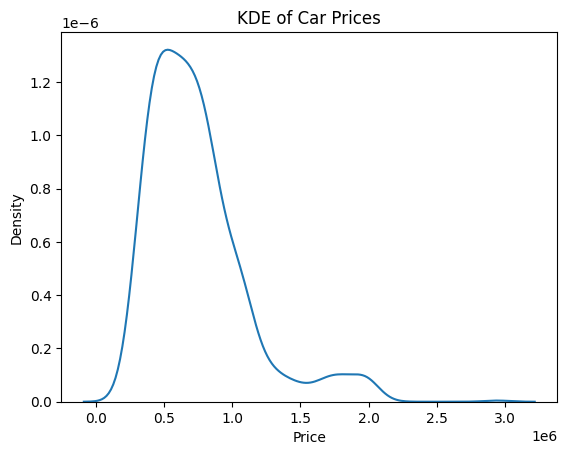

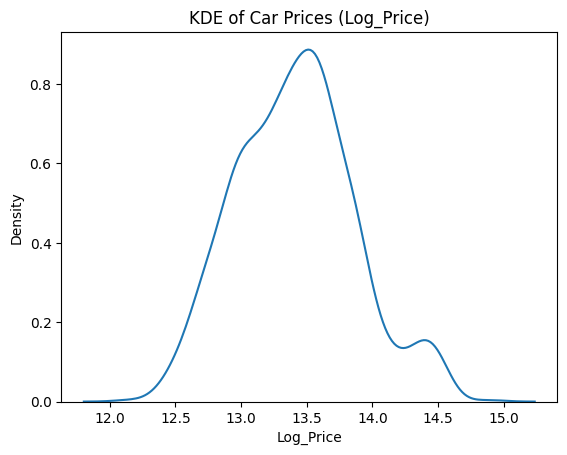

               count          mean           std        min        25%  \
Make                                                                     
Chevrolet        6.0  4.535000e+05  2.466064e+05   267000.0   288500.0   
Datsun           3.0  2.896667e+05  1.050397e+04   279000.0   284500.0   
Ford            52.0  7.211731e+05  1.409277e+05   290000.0   635000.0   
Honda           73.0  7.989726e+05  2.665091e+05   316000.0   581000.0   
Hyundai        305.0  6.918918e+05  2.791597e+05   248000.0   485000.0   
Jeep             4.0  1.499500e+06  1.525134e+05  1290000.0  1447500.0   
Kia              8.0  1.614750e+06  1.190567e+05  1369000.0  1579000.0   
MG Motors       35.0  1.869457e+06  1.216611e+05  1589000.0  1786500.0   
Mahindra        18.0  1.100167e+06  1.755493e+05   796000.0  1037000.0   
Maruti Suzuki  293.0  5.887850e+05  2.160199e+05   237000.0   411000.0   
Nissan           4.0  8.842500e+05  2.895599e+05   475000.0   782500.0   
Renault         68.0  6.625735e+05  2.

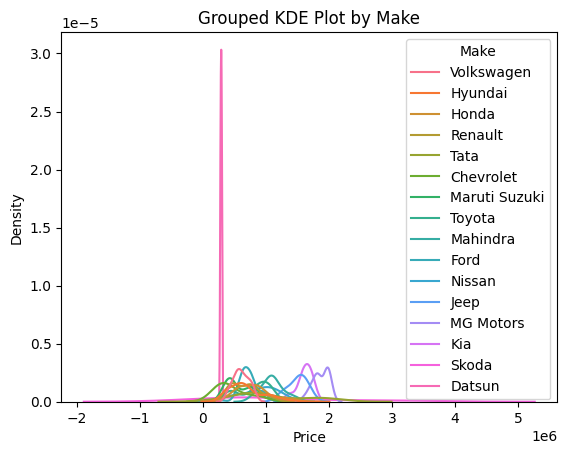

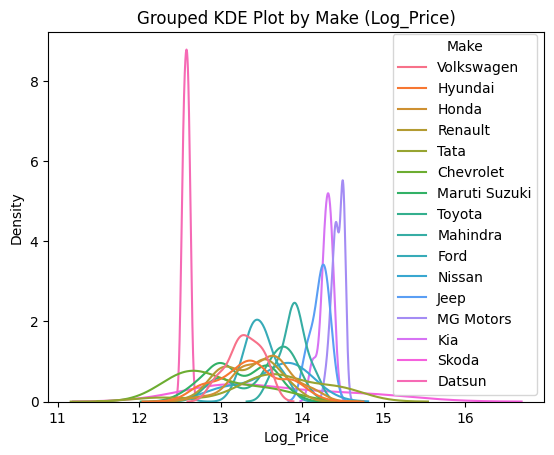

In [70]:
# 2: Summaries and KDE Plots

print(cars_df['Price'].describe(), '\n')
print(cars_df['Log_Price'].describe(), '\n')

sns.kdeplot(data=cars_df, x='Price')
plt.title('KDE of Car Prices')
plt.show()

sns.kdeplot(data=cars_df, x='Log_Price')
plt.title('KDE of Car Prices (Log_Price)')
plt.show()

print(cars_df.groupby('Make')['Price'].describe(), '\n')
print(cars_df.groupby('Make')['Price'].mean().sort_values(ascending=False), '\n')

sns.kdeplot(data=cars_df, x='Price', hue='Make', common_norm=False)
plt.title('Grouped KDE Plot by Make')
plt.show()

sns.kdeplot(data=cars_df, x='Log_Price', hue='Make', common_norm=False)
plt.title('Grouped KDE Plot by Make (Log_Price)')
plt.show()

The most expensive (top 3) car brands are MG Motors, Kia, and Jeep. The distribution of prices is right-skewed. Most of the cars are priced between \$400,000 and \$700,000.

In [71]:
# 3: Splitting the Data

X = cars_df.drop(columns=['Price'])
y = cars_df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=.2,
                                                    random_state=65)

In [72]:
# 4: Regression Models

Xn_train = X_train[['Make_Year', 'Mileage_Run', 'Seating_Capacity']]
Xn_test = X_test[['Make_Year', 'Mileage_Run', 'Seating_Capacity']]
reg1 = LinearRegression().fit(Xn_train, y_train)
y_train_pred1 = reg1.predict(Xn_train)
y_test_pred1 = reg1.predict(Xn_test)

print('Numeric Model: \n')
print('Train R2:', r2_score(y_train, y_train_pred1), '\n')
print('Train RMSE:', np.sqrt(mean_squared_error(y_train, y_train_pred1)), '\n')
print('Test R2:', r2_score(y_test, y_test_pred1), '\n')
print('Test RMSE:', np.sqrt(mean_squared_error(y_test, y_test_pred1)), '\n')

X_cat = pd.get_dummies(cars_df[['Make', 'Color', 'Body_Type', 'Fuel_Type', 'Transmission', 'Transmission_Type', 'No_of_Owners']], drop_first=True)
Xc_train = X_cat.loc[X_train.index]
Xc_test = X_cat.loc[X_test.index]
reg2 = LinearRegression().fit(Xc_train, y_train)
y_train_pred2 = reg2.predict(Xc_train)
y_test_pred2 = reg2.predict(Xc_test)
print('Categorical Model: \n')
print('Train R2:', r2_score(y_train, y_train_pred2), '\n')
print('Train RMSE:', np.sqrt(mean_squared_error(y_train, y_train_pred2)), '\n')
print('Test R2:', r2_score(y_test, y_test_pred2), '\n')
print('Test RMSE:', np.sqrt(mean_squared_error(y_test, y_test_pred2)), '\n')

X_combined = pd.concat([cars_df[['Make_Year', 'Mileage_Run', 'Seating_Capacity']], X_cat], axis=1)
Xj_train = X_combined.loc[X_train.index]
Xj_test = X_combined.loc[X_test.index]
reg3 = LinearRegression().fit(Xj_train, y_train)
y_train_pred3 = reg3.predict(Xj_train)
y_test_pred3 = reg3.predict(Xj_test)
print('Combined Model: \n')
print('Train R2:', r2_score(y_train, y_train_pred3), '\n')
print('Train RMSE:', np.sqrt(mean_squared_error(y_train, y_train_pred3)), '\n')
print('Test R2:', r2_score(y_test, y_test_pred3), '\n')
print('Test RMSE:', np.sqrt(mean_squared_error(y_test, y_test_pred3)), '\n')

Numeric Model: 

Train R2: 0.31110682962260283 

Train RMSE: 306674.8002832129 

Test R2: 0.3166008639903246 

Test RMSE: 295400.4878027807 

Categorical Model: 

Train R2: 0.7610040114171969 

Train RMSE: 180633.15075291612 

Test R2: 0.7788209452963526 

Test RMSE: 168052.89341244652 

Combined Model: 

Train R2: 0.8517289825328448 

Train RMSE: 142275.55401404595 

Test R2: 0.8421688860519506 

Test RMSE: 141961.4106742381 



The second model (categorical variables) performs better than the first model (numeric variables) because the RMSE is lower and the R2 is greater for both the training and testing data. The joint model performs the best out of the three models. The test RMSE is slighty smaller than the test RMSE for the second model, and the test R2 is slightly greater than the test R2 for the second model. It does not perform better by a significant amount, but it does perform a little bit better by the metrics.

In [ ]:
# 5: Expanding Numeric Variables

degrees = [1, 2, 3, 4, 5]
results = []

for d in degrees:
  expander = PolynomialFeatures(degree=d, include_bias=False)


**Q4.** Let's explore multiple linear regression in a two-variable case, to build more intuition about what is happening.

Suppose the model is
$$
\hat{y}_i = b_0 + b_1 z_{i1} + b_2 z_{i2}
$$
Assume that $z_{ij}$ is centered or de-meaned, so that $z_{ij} = x_{ij} - m_j$ where $m_j$ is the mean of variable $j$ and $x_{ij}$ is the original value of variable $j$ for observation $i$. Notice that this implies
$$
\dfrac{1}{N} \sum_{i=1}^N z_{ij} = 0
$$
which will simplify your calculations below substantially!

1. Write down the SSE for this model.
2. Take partial derivatives with respect to $b_0$, $b_1$, and $b_2$.
3. Verify that the average error is zero and $e \cdot z =0$ at the optimum, just as in the single linear regression case.
4. Show that the optimal intercept is $b_0^* = \bar{y}$. Eliminate $b_0^*$ from the remaining equations, and focus on $b_1$ and $b_2$.
5. Write your results as a matrix equation in the form "$Ab=C$". These are called the **normal equations**.
6. Divide both sides by $N$ and substitute $z_{ij} = x_{ij} - m_j$ back into your normal equations for $x_{ij}$. What is the matrix $A$? What is the vector $C$? Explain the intuition of your discovery.